In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from graphviz import Digraph

import torch

第四行：让 matplotlib 绘制的图表直接内嵌显示在 Notebook 页面里

In [2]:
def f(x):
    return 3 * x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

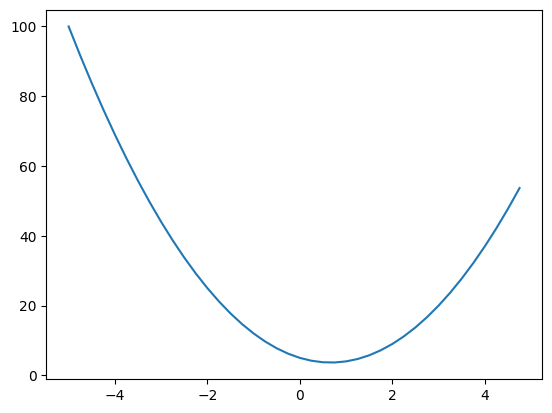

In [6]:
plt.plot(xs, ys)

$x$以$f$在$3.0$附近的变化趋势变化单位$1$时，$f$变化了多少：

In [7]:
h = 0.00000001  # 注意如果用太小的值，计算机浮点数运算会出问题。
x = 3.0
(f(x + h) - f(x)) / h

14.00000009255109

In [8]:
x = -3.0
(f(x + h) - f(x)) / h

-22.00000039920269

In [9]:
x = 2/3
(f(x + h) - f(x)) / h

0.0

In [10]:
# inputs:
a = 2.0
b = -3.0
c = 10.0

# outputs
d = a * b + c

In [11]:
a = 2.0
b = -3.0
c = 10.0

a += h
d1 = a*b + c
print('d =', d)
print('d1 =', d1)
print('slope =', (d1 - d) / h)

d = 4.0
d1 = 3.99999997
slope = -2.999999981767587


在此$(a,b,c)$处，（单独）增大$a$会导致$d$减小。该减小的速率为$3$。

同理：

在此$(a,b,c)$处，（单独）增大$b$会导致$d$增大。该增大的速率为$2$。

在此$(a,b,c)$处，（单独）增大$c$会导致$d$增大。该增大的速率为$1$。

In [12]:
class Value:
# Note the += in all derivative calculations: this accumulates the derivative
# so that after the full expression graph is traversed, each variable's derivative
# will be accounted as the sum of all paths from the final output variable to it,
# matching the chain rule for partial derivative.

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # grad is the derivative of the root with respect to this node
        # i.e. how does changing this node's value influences the value on the root
        # grad is initialized to 0: assuming NO influence to begin with.
        self._backward = lambda: None   # empty function that does nothing (e.g. for leaf nodes)
        self._prev = set(_children) # empty set if children is empty tuple
        self._op = _op  # for leaf Value, operation is empty string
                        # note that the root node is the output
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # 注意：下面存入out._backward的函数中纪录的均是self、other、out的指针/reference

    def __add__(self, other):   # self + other
        other = other if isinstance(other, Value) else Value(other)
        # note that Value(other) calls __init__

        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # chain rule on the current path:
            #   (local derivative) * (global derivative up to this node)
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other): # other + self
        return self + other
    
    def __mul__(self, other):   # self * other
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # chain rule on the current path:
            #   (local derivative) * (global derivative up to this node)
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        # reverse multiply:
        # When python cannot find a definition for other * self, it will call this function.
        return self * other

    def __neg__(self):  # -self
        return self * (-1)
    
    def __sub__(self, other):   # self - other
        return self + (-other)

    def __pow__(self, other):   # self ** other
        assert isinstance(other, (int, float)), "currently only supporting int or float powers"

        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1.0) * out.grad
        out._backward = _backward

        return out
    
    def __truediv__(self, other):   # self / other
        return self * other**(-1)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh') # (self,) in python means tuple of 1 element
        
        def _backward():
            # chain rule on the current path:
            #   (local derivative) * (global derivative up to this node)
            self.grad += (1.0 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # Don't forget self is the variable before going into exp()
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological sort:
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

        # 它保证了：
        # 1. from self backwards，每个node都被visited
        # 2. 每个node只做一次_backward()
        # 3. 每个node的_backward()只有在从self流向它的所有路径上对它的导数累加好了之后才会被调用
    
    


In [13]:
# This cell is only for visualization purposes.

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot


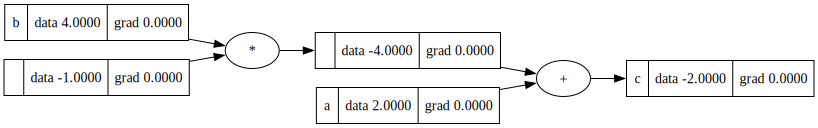

In [14]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')
c = a - b; c.label = 'c'
draw_dot(c)

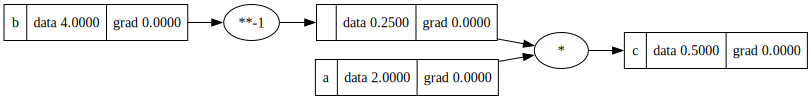

In [15]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')
c = a / b; c.label = 'c'
draw_dot(c)

In [16]:
a = Value(2.0, label='a')
print(a)    # this calls __repr__
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
print(a + b)    # this calls a.__add__(b)
print(a * b)    # this calls a.__mul__(b)
print(c + a * b)    # this calls (a.__mul__(b)).__add__(c)
                    # note this follows arithmatic order
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
print(d._prev)
print(d._op)
f = Value(-2.0, label='f')
L = d * f; L.label='L'
print(L)

Value(data=2.0)
Value(data=-1.0)
Value(data=-6.0)
Value(data=4.0)
{Value(data=10.0), Value(data=-6.0)}
+
Value(data=-8.0)


Note that the operation nodes are just for visualization purpose.

There is no separate operation node defined in our Expression Graph implementation.

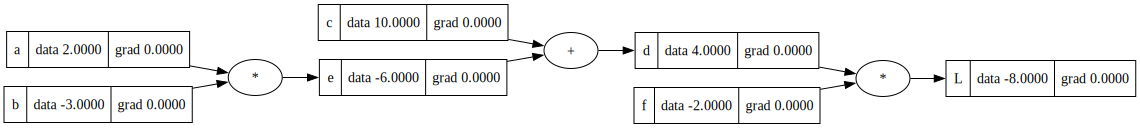

In [17]:
draw_dot(L)

上图可以想象为一次forward pass

其中inputs是所有leaf nodes：$a,b,c,f$

Forward pass的output是$L$的值。

- 在神经网络的setting下，如果我们把$L$看作Loss，那么一部分leaf nodes可以想象为weights，剩下的那部分是(training) data

相反，backpropagation需要从root node ($L$)开始

它关心的是任意node上的值的变化对$L$产生的影响。

更具体来说，backpropagation（只）关心表示weights的那些leaf nodes，因为(training) data是fixed的——我们通过改变weights来减小$L$ (i.e., loss)以训练神经网络。

In [18]:
# inline numerical gradient check for backpropagation:
def lol():
    h = 0.001
# -----------------------------------
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data
# -----------------------------------
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h # 注意这里除了d的data值（float），我们没有改变该数据结构中任何其他东西
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    #print(d)
    #print(d._prev)
    #print(L._prev)
    #print(L)

    print((L2-L1)/h)    # derivative of L with respect to d

lol()

-2.000000000000668


上面这个函数可以让我们做manual backpropagation

不过我们也可以用微积分：

比如我们知道 $L=d*f$

所以 $\frac{dL}{dd}=f$；$\frac{dL}{df}=d$

因此，在目前这个state点上，`d.grad`就等于$-2$；`f.grad`就等于$4$

当我们知道 how $d$ affects $L$ 以及 how $c$ affects $d$，我们应该可以知道 how $c$ affects $L$

因为 $d=c+e$，我们知道 $\frac{dd}{dc}=1$；$\frac{dd}{de}=1$

对于整个expression graph，$\frac{dd}{dc}$和$\frac{dd}{de}$可以被看做是“local derivative”，而类似$\frac{dL}{dc}$的这种则可以称为“global derivative”

我们可以通过Chain Rule来把$\frac{dL}{de}$和比如$\frac{dL}{dd}$及$\frac{dd}{de}$联系起来：

$\frac{dL}{de} = \frac{dL}{dd} * \frac{dd}{de}$

$\frac{dL}{dd}=-2$，$\frac{dd}{de}=1$

所以$\frac{dL}{de}=-2*1=-2$

注意，当我们想知道$\frac{dL}{de}$时，我们是在当前这个状态点上做的，即，我们把其他inputs全看成了constants。所以整个过程中并不涉及偏导数。

但是！把其他变量看作constants，令$L$对$e$求导时，我们其实就是在求偏导数。

根据多元复合函数的链式法则（Multivariate Chain Rule），**如果有多个路径可以从 $e$ 影响到 $L$，我们需要把所有路径的偏导数相加**。

已知$L=L(d,f)$，因此：

$$ \frac{\partial L}{\partial e} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} + \frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial e} $$

其中：

$\frac{\partial L}{\partial d}=f=-2$，$\frac{\partial d}{\partial e}=1+0=1$。因此前一项等于$-2$。

后一项中$e$的变化不会对$f$产生影响，因此$\frac{\partial f}{\partial e}=0$。后一项被消除。所以$\frac{\partial L}{\partial e} = -2$。与之前我们计算的出的结果一致。

可以注意到，**在一个Expression Graph中，没有连接的节点相互之间的偏导数天然就是 $0$**。

另外我们可以注意到，当一个node的children nodes间对应的运算是加法时，该node的梯度会直接传播给这些children nodes。（因为此处每个child node对该node的局部梯度均为$1$）

In [19]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

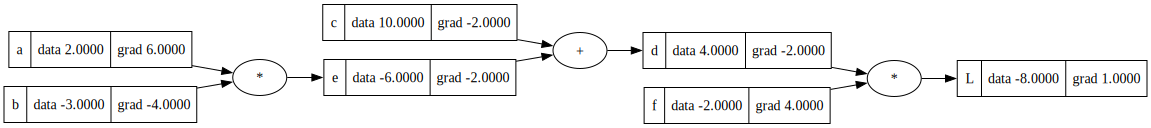

In [20]:
draw_dot(L)

因为这个expression只包含加法和乘法，我们可以知道$L(a,b,c,f)$是个性质很好的Differentiable function。它在任意一点$(a,b,c,f)$上的differential space都是一个平坦的（超）平面。It can be shown that 这个时候$L(a,b,c,f)$的梯度向量指向（局部于当前点$(a,b,c,f)$附近 i.e. 点$(a,b,c,f)$上的differential space内）$L$增幅最大的方向。

因此，a step of optimization can be done as follows：（这里假设我们想找$L$的maximum）

In [21]:
# move along the gradient for all inputs:

step_size = 0.01

a.data += step_size * a.grad
b.data += step_size * b.grad
c.data += step_size * c.grad
f.data += step_size * f.grad

# the forward pass:

e = a * b
d = c + e
L = f * d

print(L.data)

-7.286496


注意，沿梯度方向行走并不能保证这一步下来后$L$的值一定更大了。

梯度只能告诉我们在当前点$(a,b,c,f)$上$L$增幅最大的方向（即 它保证的是differential space上$L$的增量），但在实际的observable space中（`step_size`是个finite value）我们并不能保证这一步内不存在我们没有capture到的$L$的梯度变化（就比如$L$在行进方向上突然凹下去个洞；不过这在$L(a,b,c,f)$的differential space上是不可能的情况）。

A trivial fact but I still want to mention：我们可以把这一步拆成分别沿$a,b,c,f$走的四步（注意这四步用的是对原起始点$(a,b,c,f)$求出来的梯度的四个分量）。不过无论我们走这四步的顺序如何，终点都是一样的，因此终点的$L$值也一定是一样的。

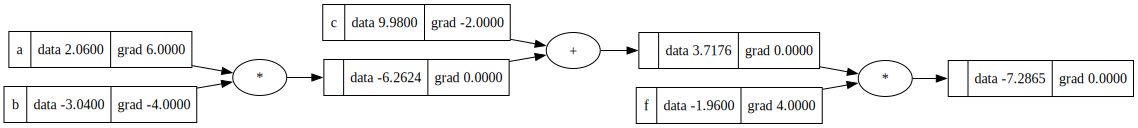

In [22]:
draw_dot(L)

Example of an activation function: $tanh$

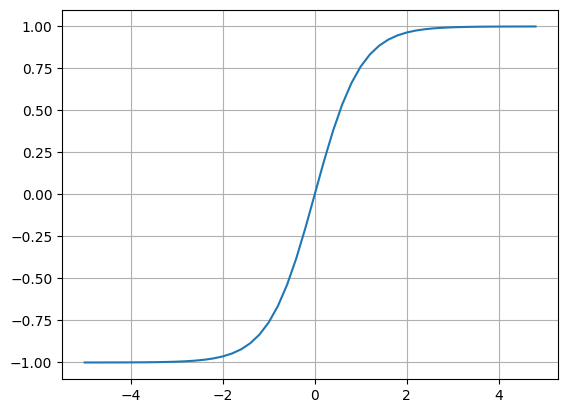

In [23]:
plt.plot( np.arange(-5,5,0.2), np.tanh( np.arange(-5,5,0.2) ) ); plt.grid();

When a neuron has $n$ inputs, it is called a $n$-dimensional neuron.

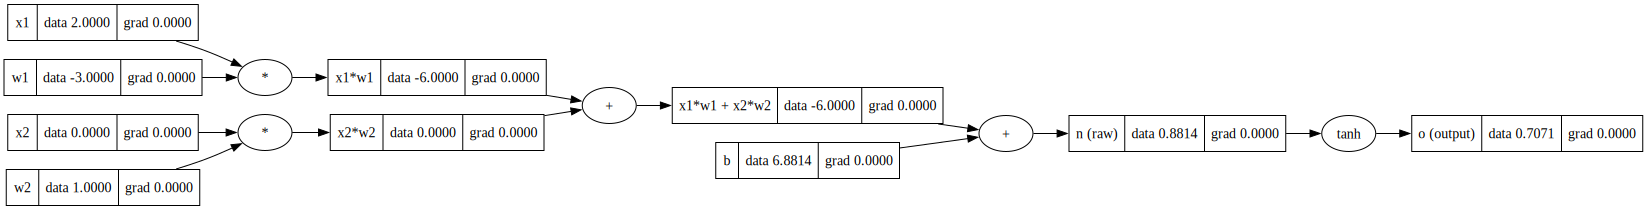

In [24]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# raw activation: x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n (raw)'
# activation: using tanh
o = n.tanh(); o.label = 'o (output)'
draw_dot(o)

Now, we can do manual backpropagation of this neuron.

For $o=tanh(n)$, we have $\frac{do}{dn}=1-o^2$

In [25]:
1 - o.data**2

0.4999999999999999

In [26]:
o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5 # flows from n due to + operation
b.grad = 0.5    # flows from n due to + operation
x1w1.grad = 0.5 # flows from x1w1x2w2 due to + operation
x2w2.grad = 0.5 # flows from x1w1x2w2 due to + operation
x2.grad = w2.data * x2w2.grad   # product rule + chain rule (note there is only one path to o)
w2.grad = x2.data * x2w2.grad   # product rule + chain rule (note there is only one path to o)
x1.grad = w1.data * x1w1.grad   # product rule + chain rule (note there is only one path to o)
w1.grad = x1.data * x1w1.grad   # product rule + chain rule (note there is only one path to o)

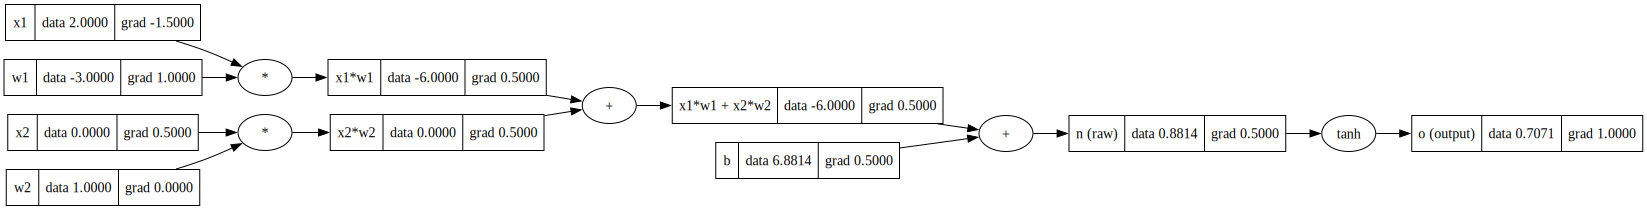

In [27]:
draw_dot(o)

Now, we can try using the auto backpropagation function `_backward`

In [28]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# raw activation: x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n (raw)'
# activation: using tanh
o = n.tanh(); o.label = 'o (output)'

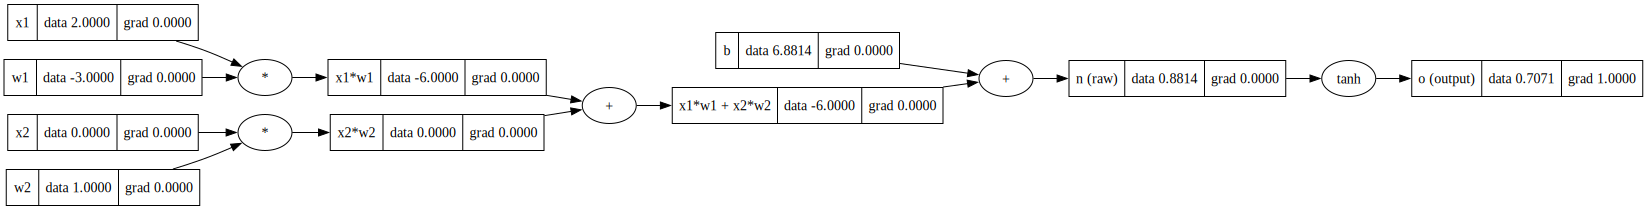

In [29]:
o.grad = 1.0    # the "initial condition" for backpropagation
draw_dot(o)

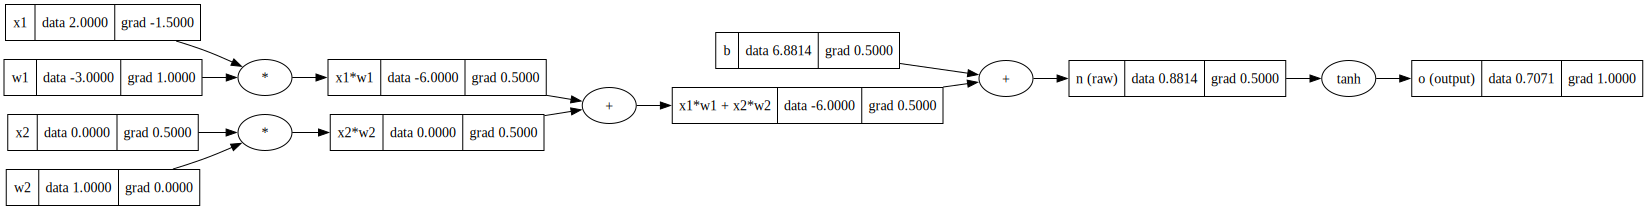

In [30]:
o._backward()
n._backward()
b._backward()   # note that this is still the initialized empty function, as b is not resulting from any operation
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
# we escape the rest of the leaf nodes in which _backward() will be calling empty function as well.
draw_dot(o)

在作为user interface的backward()中，为了自动化上述从后往前对expression graph中nodes的遍历，需要用到topological sort。

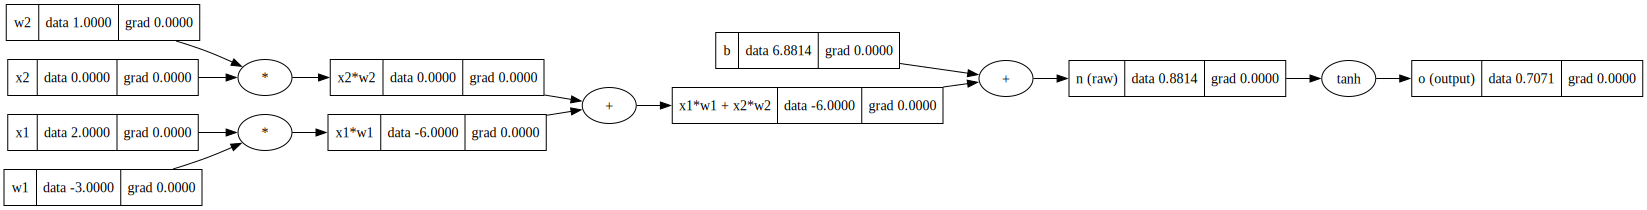

In [31]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# raw activation: x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n (raw)'
# activation: using tanh
o = n.tanh(); o.label = 'o (output)'
draw_dot(o)

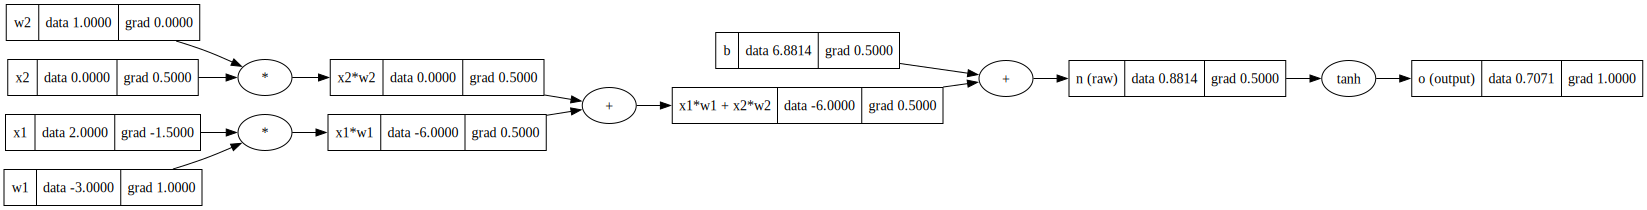

In [32]:
o.backward()
draw_dot(o)

Replace $tanh(x)$ with more atomic operation: $\frac{e^{2x}-1}{e^{2x}+1}$

Note that this is mathematically equivalent to just using $tanh(x)$

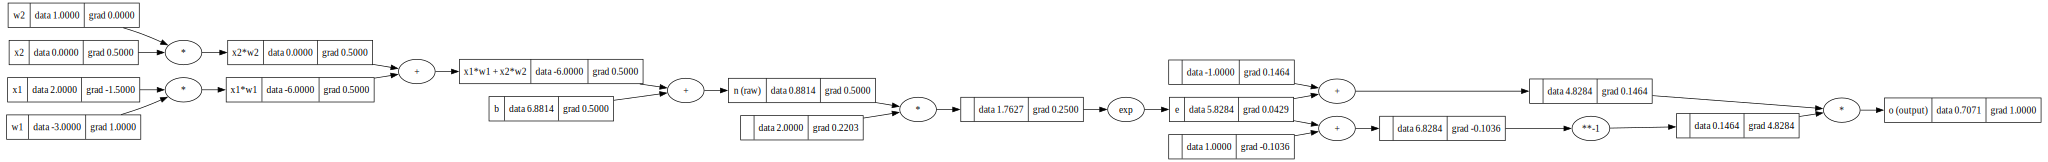

In [33]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# raw activation: x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n (raw)'
# activation: using one of the atomic definitions of tanh
e = (2*n).exp(); e.label = 'e'
o = (e - 1)/(e + 1); o.label = 'o (output)'
o.backward()
draw_dot(o)

Value in micrograd is essentially an implementation of scalar-valued Tensor in pytorch.

Tensor in pytorch can also hold array(s) of scalars and conduct parallel computing.

In [34]:
t = torch.Tensor( [ [1,2,3] , [4,5,6] ] )
print(t)
print(t.shape)
print('The default precision of pytorch tensors is single precision:', t.dtype)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
The default precision of pytorch tensors is single precision: torch.float32


PyTorch version of what we have done so far:

In [35]:
# Leaf nodes:
x1 = torch.Tensor( [2.0] ).double(); x1.requires_grad = True
x2 = torch.Tensor( [0.0] ).double(); x2.requires_grad = True
w1 = torch.Tensor( [-3.0] ).double(); w1.requires_grad = True
w2 = torch.Tensor( [1.0] ).double(); w2.requires_grad = True
b = torch.Tensor( [6.8813735870195432] ).double(); b.requires_grad = True

# Forward pass:
print('Forward pass:')

n = w1*x1 + w2*x2 + b
#n.retain_grad()
o = torch.tanh(n)
#o.retain_grad()

print(o.data.item())    # .item grab the value out from the tensor object

# Backward pass:
print('Backward pass:')

o.backward()

print('w1', w1.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('x2', x2.grad.item())

Forward pass:
0.7071066904050358
Backward pass:
w1 1.0000002567688737
x1 -1.5000003851533106
w2 0.0
x2 0.5000001283844369


在pytorch中，被直接initialize的Tensor会被当做leaf node，并且被默认设置 `.requires_grad = False`

`.requires_grad` 是一个“意图声明”，`.requires_grad = True` 并不是该叶节点自己要去执行多么复杂的反向计算，而是在向整个引擎声明：“我最终需要更新这个变量（比如神经网络的权重），请务必把通向这个变量的梯度路径都给我建好！”

（`.requires_grad` 默认设置为 `False` 的意图是：pytorch默认被直接initialize的新Tensor会被当做fixed输入数据，而不是需要更新的权重）

当我们执行比如 `c = a + b` 时，PyTorch 在执行这步前向传播时，会去检查输入（子节点 `a` 和 `b`）：

- 如果 a 和 b 的 `requires_grad` 都是 False，PyTorch 就不会去为 c 构建那个用来算梯度的 _backward()
- 只要 a 或 b 中有任何一个叶节点带上了 `requires_grad=True` 的标记，PyTorch 在生成父节点 c 时，c 就会立刻被“传染”。c 的 requires_grad 会自动被设为 True，并将其 `_backward()` 构建好。

注意，在 PyTorch 中，非叶节点的 `requires_grad` 属性通常不是手动设置的，而是由它的子节点（输入）决定的。这样保证了只要图的内部还有需要更新的参数，梯度路径就不会被意外切断。

In [36]:
print(o)
print(o.item())
print(o.data)
print(o.data.item())
print(w1.grad)
print(w1.grad.item())
print('-' * 10)
print(n.grad)
print(o.grad)

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
0.7071066904050358
tensor([0.7071], dtype=torch.float64)
0.7071066904050358
tensor([1.0000], dtype=torch.float64)
1.0000002567688737
----------
None
None


C:\Users\xiaoy\AppData\Local\Temp\ipykernel_41656\3122463705.py:8: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:497.)
  print(n.grad)
C:\Users\xiaoy\AppData\Local\Temp\ipykernel_41656\3122463705.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Te

在PyTorch中，默认情况下只有Leaf Tensors才保留计算出来的梯度，非叶节点（即中间计算结果）的梯度在反向传播完成后会被自动释放，以节省内存。

`x1`, `x2`, `w1`, `w2`, `b` 是你直接创建并设置了 `requires_grad=True` 的 Tensor，它们属于叶节点，所以能成功打印出 `.grad`。

而 `o` 和 `n` 是通过运算产生的非叶子节点（中间结果）。

如上述UserWarning所说，如果你确实想要观察/保留像 `o` 这样的非叶节点的梯度，你需要在调用 `.backward()` 之前显式地调用 `o.retain_grad()` 函数。

In [37]:
class Neuron:

    def __init__(self, nin):
        # nin: dimension of the neuron (how many inputs it takes)
        self.w = [ Value(random.uniform(-1,1)) for _ in range(nin) ]
        self.b = Value( random.uniform(-1,1) )
    
    def __call__(self, x):
        # this is called when executing n(x) where n is a Neuron instance
        # we do forward pass of this neuron here

        # raw activation:
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)  # this is just to start the sum from b, more efficient than + b

        out = act.tanh()

        return out 

class Layer:
    # A list of independent neurons
    def __init__(self, nin, nout):
        # this layer contains nout number of neurons of nin-dimension
        # note: by outputs of a layer we mean the set of outputs from all the neurons in the layer
        #       and thus, nout == number of neurons
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        # feed the inputs x into each neuron in this layer
        # get the output from each neuron
        # return the outputs as a list, or the single output.

        outs = [neuron(x) for neuron in self.neurons]

        return outs[0] if len(outs) == 1 else outs

class MLP:
    # NOTE: input layer只是个向量，并不包含神经元！
    #       但output layer确实包含的是神经元

    def __init__(self, nin, nouts):
        # nin: number of inputs
        # nouts: a list, with each element representing a hidden layer
        #        or the output layer (the last element),
        #        numbering the number of neurons of that layer.

        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        # 注：每层宽度可以不等，只要下一层神经元维度等于上一层宽度就可以
    
    def __call__(self, x):
        # 接收input features
        # 返回该MLP在output layer的最终输出Value(s)
        for layer in self.layers:
            x = layer(x)    # 注意：这里输入的Values在逐层**更新**
        
        return x

In [38]:
# example inputs:
x = [2.0,3.0]

n = Neuron(2)   # a neuron that takes 2 inputs (and output 1 output)
n(x)    # the output

Value(data=-0.9995649209131553)

In [39]:
# example inputs:
x = [2.0,3.0]

n = Layer(2,3)  # a layer (of neurons) that contains 3 neurons, each taking 2 inputs
n(x)    # the list (of 3) outputs

[Value(data=0.8058541488586694),
 Value(data=-0.6400445474550205),
 Value(data=0.9863732234416434)]

In [ ]:
# example inputs:
x = [2.0,3.0,-1.0]

n = MLP(3, [4,4,1])   # 3 inputs, 2 hidden layers of size 4, and an output layer of size 1.
# Note that currently weights and biases of the neurons in this MLP are still random values from initialization.
n(x)

Value(data=-0.2447100992554899)

$n(x)$是一次forward pass后最终输出的Value。这个Value“包含”了从inputs经过整个MLP计算到最终output的expression graph：

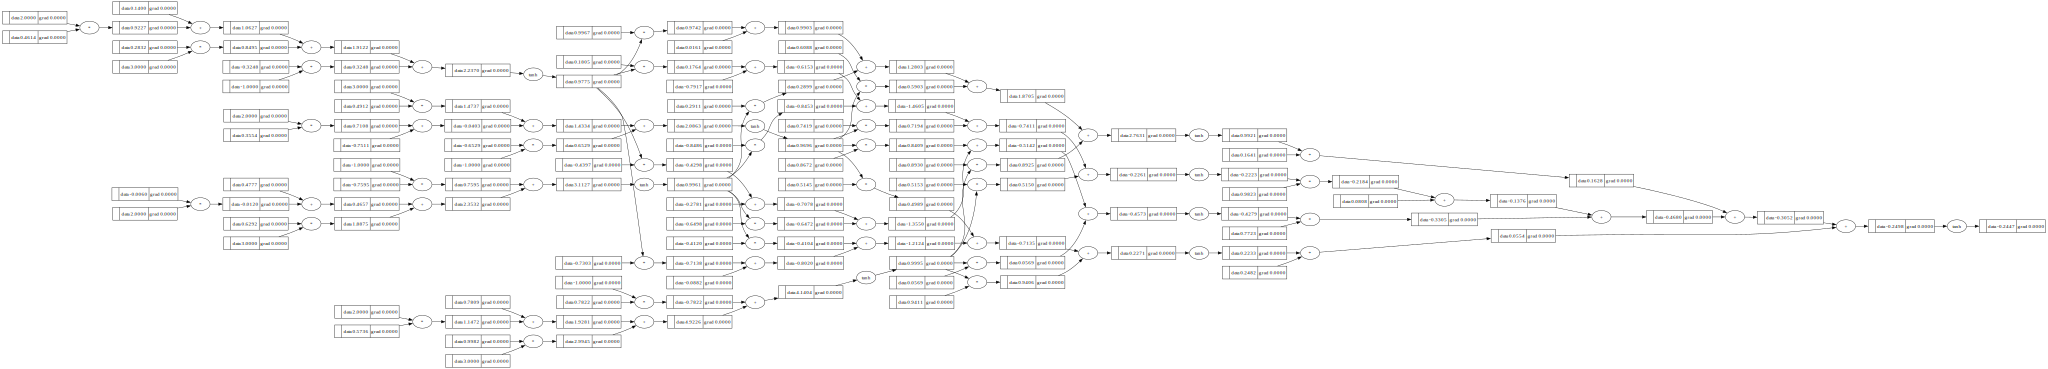

In [41]:
draw_dot(n(x))

In [42]:
# A tiny example training dataset:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]   # a dataset of 4 training examples

# Targets:
ys = [
    1.0,
    -1.0,
    -1.0,
    1.0,
]

# Forward passes:
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.2447100992554899),
 Value(data=-0.2431110720945904),
 Value(data=-0.8071346915625295),
 Value(data=-0.5653224865973614)]

这四个`Value`s分别“包含”了4次forward passes中的每一张从输入到最终输出的完整expression graph。

但注意，这四次forward passes都用的是一个神经网络（$n$），因此它们的计算过程中用的都是内存上的同一组weights and biases：即MLP $n$的parameters。

MSE (Mean Squared Error): (also called L2 error)

In [43]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=1.5493032311886112),
 Value(data=0.5728808491858004),
 Value(data=0.037197027198680635),
 Value(data=2.4502344870473465)]

In [44]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
# 注意，(yout - ygt)**2 for ygt, yout in zip(ys, ypred)是一个Generator Expression，它会生成一个Generator。
# 把Generator放进sum()里时，Generator会依次把(yout - ygt)**2吐给sum()。
# sum()底层相当于在做 0 + Value(A) + Value(B) + Value(C)
# 注意，这里0 + Value是个对于Value的右加，因为int 0不知道该如何加Value，这里我们需要Value class里面有定义__radd__

loss

Value(data=4.609615594620439)

注意，这个loss Value“包含”了**用同一组weights and biases**的4次forward passes的完整Expression Graph。

此时我们以loss为root node来进行反向传播，即可得到这4次forward passes（包含整个tiny training set）求出来的MSE loss对这同一组weights and biases的导数（梯度）：

In [45]:
loss.backward()

In [51]:
n.layers[0].neurons[0].w[0].grad

-0.06875281557066318

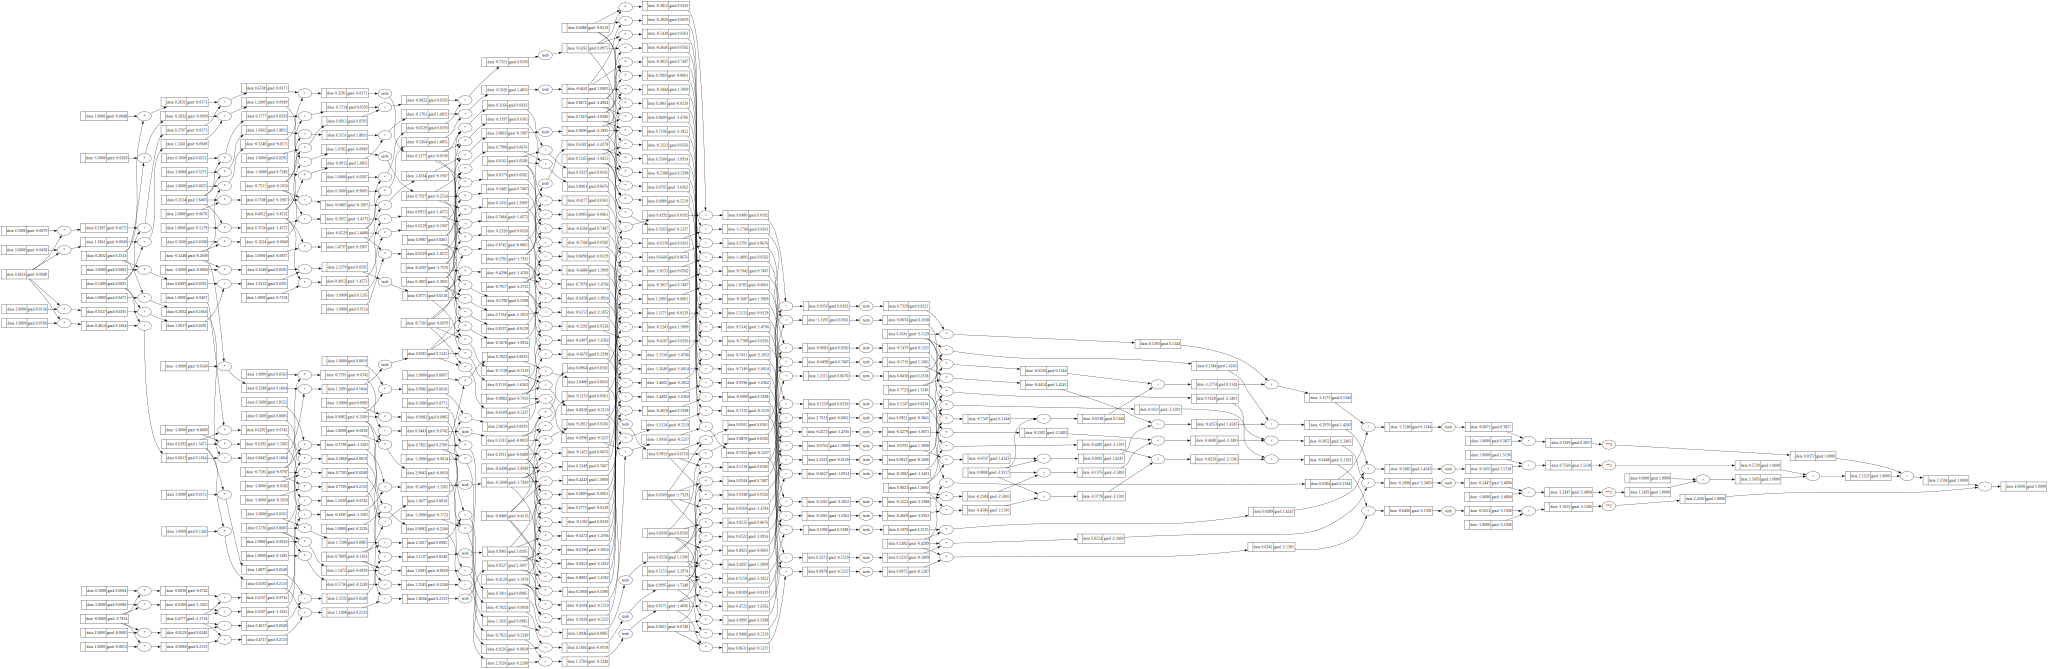

In [52]:
draw_dot(loss)